In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Fake Review Detection - LightGBM") \
    .master("local[*]") \
    .getOrCreate()

print("Spark session created!")

Spark session created!


In [3]:
import os
for root, dirs, files in os.walk("/home/jovyan/work"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/home/jovyan/work/fake_review_predictions.csv
/home/jovyan/work/lgbm_results (2).csv
/home/jovyan/work/part-00000-5d7d137c-d451-4b65-b9c2-3c3d0bbcd7f8-c000.csv


In [4]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("part-00000-5d7d137c-d451-4b65-b9c2-3c3d0bbcd7f8-c000.csv")

print(f"Loaded {df.count()} reviews")
df.printSchema()

Loaded 1047184 reviews
root
 |-- user_id: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- review_stars: string (nullable = true)
 |-- date: string (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: string (nullable = true)
 |-- funny: string (nullable = true)
 |-- cool: string (nullable = true)
 |-- clean_text: string (nullable = true)
 |-- clean_text_no_stopwords: string (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- word_count: string (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- business_stars: string (nullable = true)
 |-- review_count: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- is_open: string (nullable = true)
 |-- user_review_count: string (nullable = true)
 |-- yelping_since: string (nullable = true)
 |-- user_useful: string (nullable = true)
 |-- user_funny: string (

In [5]:
from pyspark.sql.functions import col, to_timestamp
from pyspark.sql.types import FloatType

num_cols = [
    'review_stars', 'useful', 'funny', 'cool', 'word_count',
    'business_stars', 'review_count', 'is_open',
    'user_review_count', 'user_useful', 'user_funny', 'user_cool'
]

for c in num_cols:
    df = df.withColumn(c, col(c).cast(FloatType()))

df = df.withColumn("date", to_timestamp(col("date")))
df = df.withColumn("yelping_since", to_timestamp(col("yelping_since")))

print("Columns cast successfully!")
df.printSchema()

Columns cast successfully!
root
 |-- user_id: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- review_stars: float (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: float (nullable = true)
 |-- funny: float (nullable = true)
 |-- cool: float (nullable = true)
 |-- clean_text: string (nullable = true)
 |-- clean_text_no_stopwords: string (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- word_count: float (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- business_stars: float (nullable = true)
 |-- review_count: float (nullable = true)
 |-- categories: string (nullable = true)
 |-- is_open: float (nullable = true)
 |-- user_review_count: float (nullable = true)
 |-- yelping_since: timestamp (nullable = true)
 |-- user_useful: float (nullable = true)
 |-- user_funny: float (n

In [6]:
from pyspark.sql.functions import when, abs as spark_abs, datediff, lit

df = df.withColumn("suspicion_score",
    when(col("user_review_count") <= 2, 2).otherwise(0) +
    when((col("review_stars") == 1) | (col("review_stars") == 5), 1).otherwise(0) +
    when(col("word_count") <= 10, 2).otherwise(0) +
    when((col("useful") == 0) & (col("funny") == 0) & (col("cool") == 0), 1).otherwise(0) +
    when(spark_abs(col("review_stars") - col("business_stars")) >= 2, 1).otherwise(0) +
    when((col("user_useful") == 0) & (col("user_funny") == 0) & (col("user_cool") == 0), 1).otherwise(0)
)

df = df.withColumn("is_fake", when(col("suspicion_score") >= 4, 1).otherwise(0))

print("Label distribution:")
df.groupBy("is_fake").count().show()

Label distribution:
+-------+------+
|is_fake| count|
+-------+------+
|      1| 55251|
|      0|991933|
+-------+------+



In [7]:
from pyspark.sql.functions import datediff

df = df.withColumn("account_age_days", datediff(col("date"), col("yelping_since")))

# Filter invalid entries
df = df.filter(
    (col("review_stars") >= 1) & (col("review_stars") <= 5) &
    (col("word_count") < 2000) &
    (col("text").isNotNull())
)

print(f"After filtering: {df.count()} reviews")

After filtering: 362256 reviews


In [8]:
fake_df = df.filter(col("is_fake") == 1).limit(50000)
genuine_df = df.filter(col("is_fake") == 0).limit(50000)

balanced_df = fake_df.union(genuine_df)

print(f"Balanced dataset size: {balanced_df.count()}")
balanced_df.groupBy("is_fake").count().show()

Balanced dataset size: 96152
+-------+-----+
|is_fake|count|
+-------+-----+
|      1|46152|
|      0|50000|
+-------+-----+



In [9]:
import pandas as pd

pdf = balanced_df.select(
    "text", "review_count", "is_open", "account_age_days", "is_fake"
).toPandas()

pdf["review_count"] = pd.to_numeric(pdf["review_count"], errors="coerce")
pdf["is_open"] = pd.to_numeric(pdf["is_open"], errors="coerce")
pdf["account_age_days"] = pd.to_numeric(pdf["account_age_days"], errors="coerce")
pdf = pdf.dropna()

print(f"Pandas df shape: {pdf.shape}")
pdf.head()

Pandas df shape: (84630, 5)


,text,review_count,is_open,account_age_days,is_fake
0,There are new owners here. Way over priced and...,146.0,1.0,567.0,1
1,One of my favorite places in Reno. Very cool p...,170.0,1.0,526.0,1
3,I came in asked for a simple naval piercing an...,46.0,1.0,0.0,1
4,"Great place, flavor was on point, it has a rea...",119.0,1.0,71.0,1
5,Couldn't be happier with the quick turnaround ...,11.0,1.0,747.0,1


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import numpy as np

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=5, sublinear_tf=True)
X_text = tfidf.fit_transform(pdf["text"].fillna(""))

# Tabular features
X_tab = csr_matrix(pdf[["review_count", "is_open", "account_age_days"]].values)

# Combine
X = hstack([X_text, X_tab])
y = pdf["is_fake"].values

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (84630, 50003)


In [11]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 59274 | Val: 12661 | Test: 12695


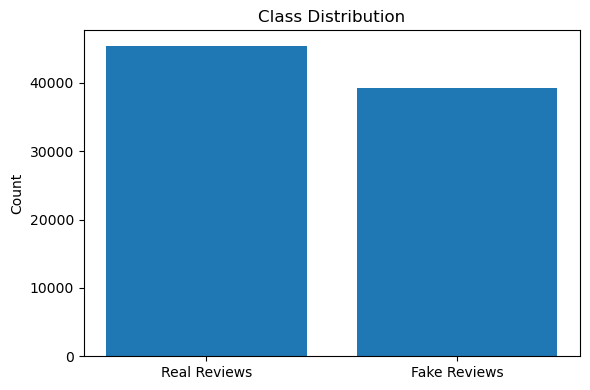

In [26]:
import matplotlib.pyplot as plt

# Use the pandas df we already have
pdf['text_length'] = pdf['text'].astype(str).apply(len)

# Plot 1 - Class Distribution
class_counts = pdf['is_fake'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Real Reviews', 'Fake Reviews'], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

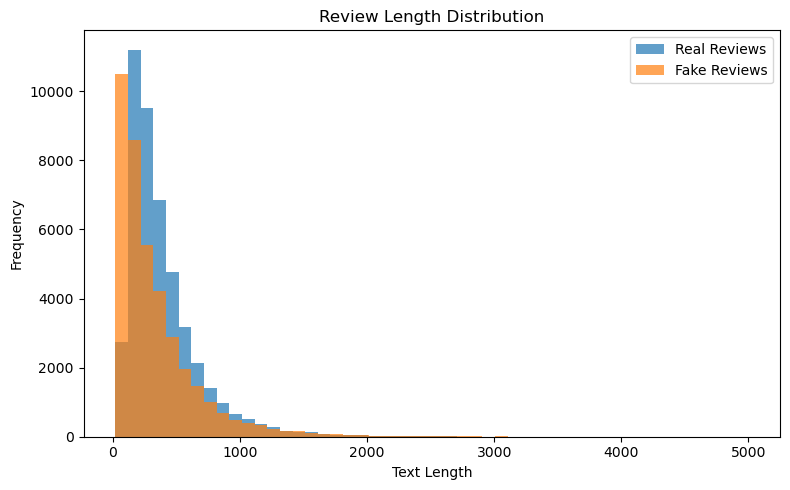

In [27]:
# Plot 2 - Review Length Distribution
plt.figure(figsize=(8, 5))
plt.hist(pdf[pdf['is_fake'] == 0]['text_length'], bins=50, alpha=0.7, label='Real Reviews')
plt.hist(pdf[pdf['is_fake'] == 1]['text_length'], bins=50, alpha=0.7, label='Fake Reviews')
plt.title("Review Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

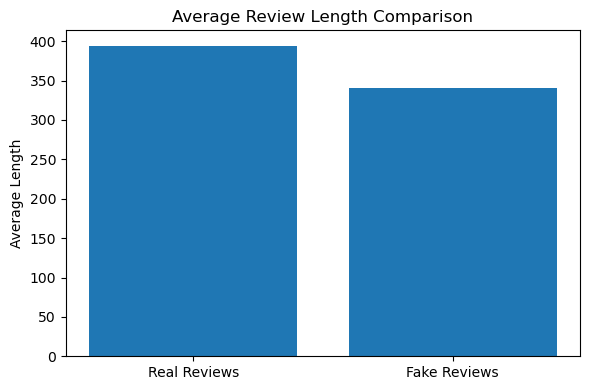

In [28]:
# Plot 3 - Average Length
avg_lengths = pdf.groupby('is_fake')['text_length'].mean()
plt.figure(figsize=(6, 4))
plt.bar(['Real Reviews', 'Fake Reviews'], avg_lengths.values)
plt.ylabel("Average Length")
plt.title("Average Review Length Comparison")
plt.tight_layout()
plt.show()

In [13]:
import sys
!{sys.executable} -m pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 3.2 MB/s eta 0:00:0000:0100:010m


In [14]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(10)]
)

print("Training complete!")

[LightGBM] [Info] Number of positive: 27452, number of negative: 31822
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.599064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1029325
[LightGBM] [Info] Number of data points in the train set: 59274, number of used features: 28972
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 30 rounds
[10]	valid_0's binary_logloss: 0.635273
[20]	valid_0's binary_logloss: 0.606512
[30]	valid_0's binary_logloss: 0.589033
[40]	valid_0's binary_logloss: 0.578198
[50]	valid_0's binary_logloss: 0.570486
[60]	valid_0's binary_logloss: 0.564536
[70]	valid_0's binary_logloss: 0.560193
[80]	valid_0's binary_logloss: 0.55621
[90]	valid_0's binary_logloss: 0.553491
[100]	valid_0's 

In [18]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      6816
           1       0.70      0.72      0.71      5879

    accuracy                           0.73     12695
   macro avg       0.73      0.73      0.73     12695
weighted avg       0.73      0.73      0.73     12695

AUC Score: 0.7983


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      6816
           1       0.70      0.72      0.71      5879

    accuracy                           0.73     12695
   macro avg       0.73      0.73      0.73     12695
weighted avg       0.73      0.73      0.73     12695

AUC Score: 0.7983


In [20]:
import pandas as pd

results_df = pd.DataFrame({
    "actual_target": y_test,
    "predicted_target": y_pred,
    "prediction_probability": y_prob
})

results_df.to_csv("lgbm_pyspark_results.csv", index=False)
print("Results saved!")
results_df.head()

Results saved!


,actual_target,predicted_target,prediction_probability
0,1,1,0.880888
1,1,1,0.829079
2,0,0,0.362024
3,0,0,0.068813
4,0,0,0.156494


In [22]:
import pandas as pd

results_df = pd.DataFrame({
    "actual_target": y_test,
    "predicted_target": y_pred,
    "prediction_probability": y_prob
})

results_df.to_csv("fake_review_predictions.csv", index=False)
print(" Prediction CSV saved!")
results_df.head()

 Prediction CSV saved!


,actual_target,predicted_target,prediction_probability
0,1,1,0.880888
1,1,1,0.829079
2,0,0,0.362024
3,0,0,0.068813
4,0,0,0.156494


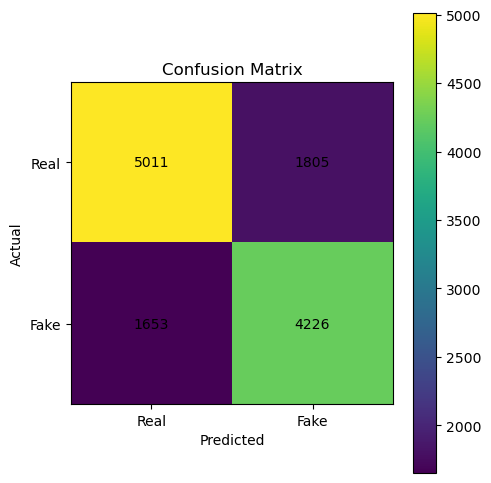

In [24]:
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()

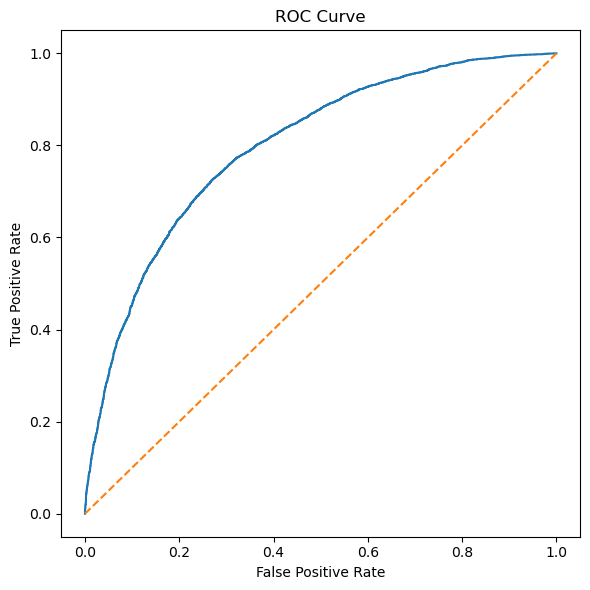

In [25]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()